# 📧 Spam / Ham / Smishing Detection — NLP Project
### Spring 2025–2026 | Dr. Wafaa Samy

**Project Idea 1 — Multi-Class Message Classification**
A system that classifies any text message into **Spam**, **Ham (legitimate)**, or **Smishing (SMS phishing)**
using **7 Machine Learning algorithms** with full overfitting analysis and a GUI application.

---
| Item | Details |
|------|---------|
| **Dataset** | A Balanced Dataset for Spam and Smishing Detection — 10,191 messages |
| **Classes** | Ham · Spam · Smishing (perfectly balanced, 3,397 each) |
| **Algorithms** | Naive Bayes · Logistic Regression · SVM · Random Forest · KNN · XGBoost · Decision Tree |
| **Features** | TF-IDF (unigrams + bigrams) + URL / Email / Phone binary flags |


## 1. Import Libraries

In [1]:
import re, string, warnings, pickle, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, learning_curve)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve)
from sklearn.calibration import CalibratedClassifierCV
import scipy.sparse as sp

from sklearn.naive_bayes      import MultinomialNB
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import LinearSVC
from sklearn.ensemble         import RandomForestClassifier
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.tree             import DecisionTreeClassifier
from xgboost                  import XGBClassifier

# Plot style
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.family': 'DejaVu Sans'})
COLORS = {'ham': '#1D9E75', 'spam': '#E24B4A', 'smishing': '#7F77DD'}
print("✅ All libraries imported.")


✅ All libraries imported.


## 2. Load & Explore Dataset

The dataset contains **10,191 SMS/email messages** perfectly balanced across 3 classes:
- 🟢 **Ham** — legitimate messages (3,397)
- 🔴 **Spam** — unsolicited promotional messages (3,397)
- 🟣 **Smishing** — SMS phishing attacks, impersonating banks/services (3,397)

Extra binary columns: `URL`, `EMAIL`, `PHONE` — whether each flag appears in the message.


In [2]:
DATASET_PATH = r'A Balanced Dataset for Spam and Smishing Detection/Dataset_10191.csv'
df = pd.read_csv(DATASET_PATH, encoding='latin-1')

# Standardise column names
df.columns = [c.strip().upper() for c in df.columns]
df.rename(columns={'TEXT': 'text', 'LABEL': 'label'}, inplace=True)
df['label'] = df['label'].str.strip().str.lower()

# Binary flags (Yes/No → 1/0)
for col in ['URL', 'EMAIL', 'PHONE']:
    df[col] = (df[col].str.strip().str.lower() == 'yes').astype(int)

print("Dataset shape :", df.shape)
print()
print("Class distribution:")
print(df['label'].value_counts())
print()
print("Missing values :", df.isnull().sum().sum())
print()
df.head(6)


Dataset shape : (10191, 5)

Class distribution:
label
ham         3397
smishing    3397
spam        3397
Name: count, dtype: int64

Missing values : 0



,label,text,URL,EMAIL,PHONE
0,ham,Hi! You just spoke to DEEPAK. We'd like to kno...,0,0,0
1,ham,Yay can't wait to party together!,0,0,0
2,ham,At what time are you coming.,0,0,0
3,smishing,"Dear customer your PAY2TMKYC has been expired,...",0,0,1
4,ham,Yo you around? A friend of mine's lookin to pi...,0,0,0
5,smishing,Not heard from U4 a while. Call 4 rude chat pr...,0,0,1


## 3. Exploratory Data Analysis (EDA)

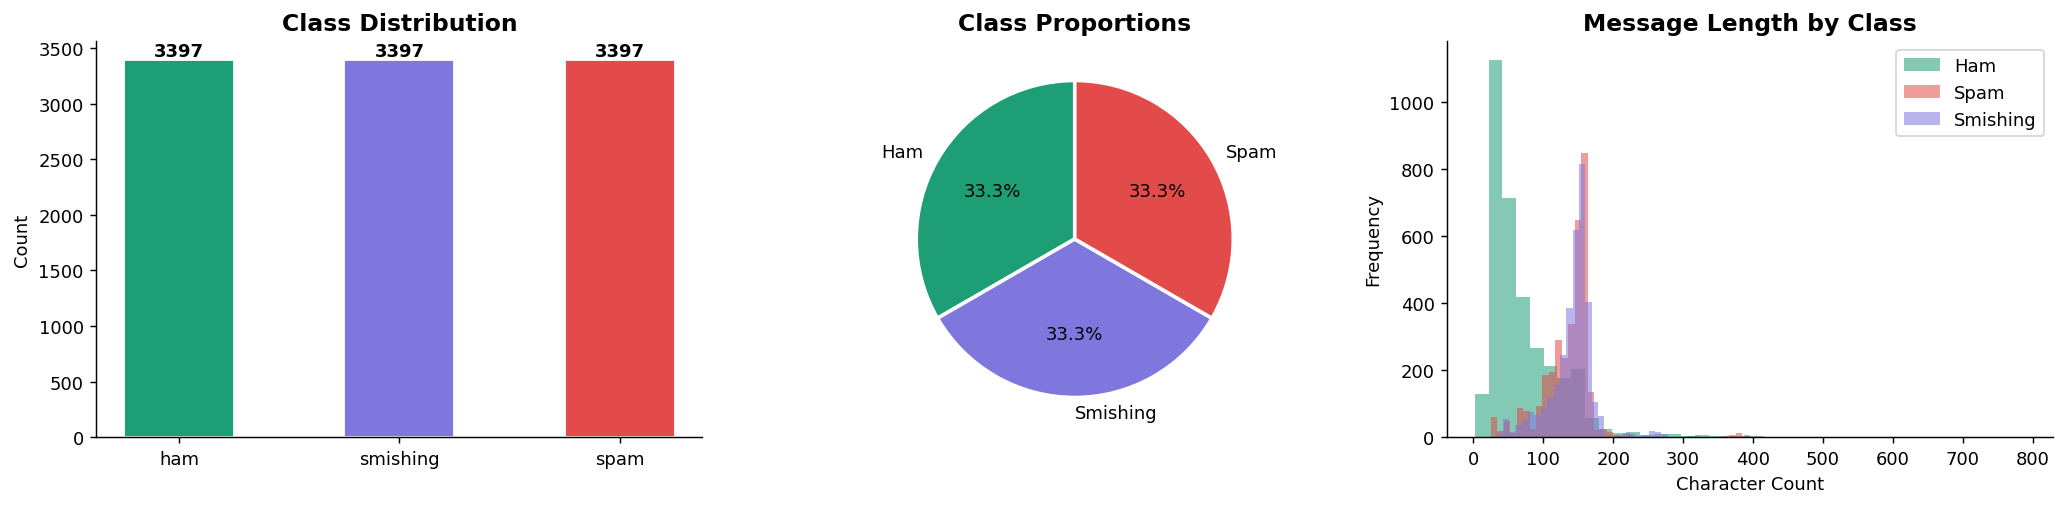


── Message Length Statistics ──────────────────────────────────
         msg_len                                                word_count  \
           count   mean   std   min    25%    50%    75%    max      count   
label                                                                        
ham       3397.0   70.8  56.9   2.0   34.0   52.0   91.0  790.0     3397.0   
smishing  3397.0  142.5  34.6  33.0  131.0  148.0  159.0  396.0     3397.0   
spam      3397.0  135.9  38.5  25.0  120.0  145.0  157.0  394.0     3397.0   

                                                    
          mean   std  min   25%   50%   75%    max  
label                                               
ham       14.1  11.3  1.0   7.0  11.0  18.0  162.0  
smishing  23.1   6.1  5.0  21.0  24.0  27.0   68.0  
spam      23.0   7.0  3.0  20.0  24.0  27.0   61.0  


In [3]:
# ── 3.1 Class distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
counts = df['label'].value_counts()
bar_colors = [COLORS[l] for l in counts.index]

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=bar_colors,
                   edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=[l.capitalize() for l in counts.index],
            autopct='%1.1f%%', colors=bar_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportions', fontweight='bold', fontsize=13)

# Message length by class
df['msg_len']   = df['text'].apply(len)
df['word_count']= df['text'].apply(lambda x: len(str(x).split()))

for label, color in COLORS.items():
    axes[2].hist(df[df['label']==label]['msg_len'], bins=40,
                 alpha=0.55, color=color, label=label.capitalize())
axes[2].set_title('Message Length by Class', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Character Count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('plot_01_eda_overview.png', bbox_inches='tight')
plt.show()

print("\n── Message Length Statistics ──────────────────────────────────")
print(df.groupby('label')[['msg_len', 'word_count']].describe().round(1))


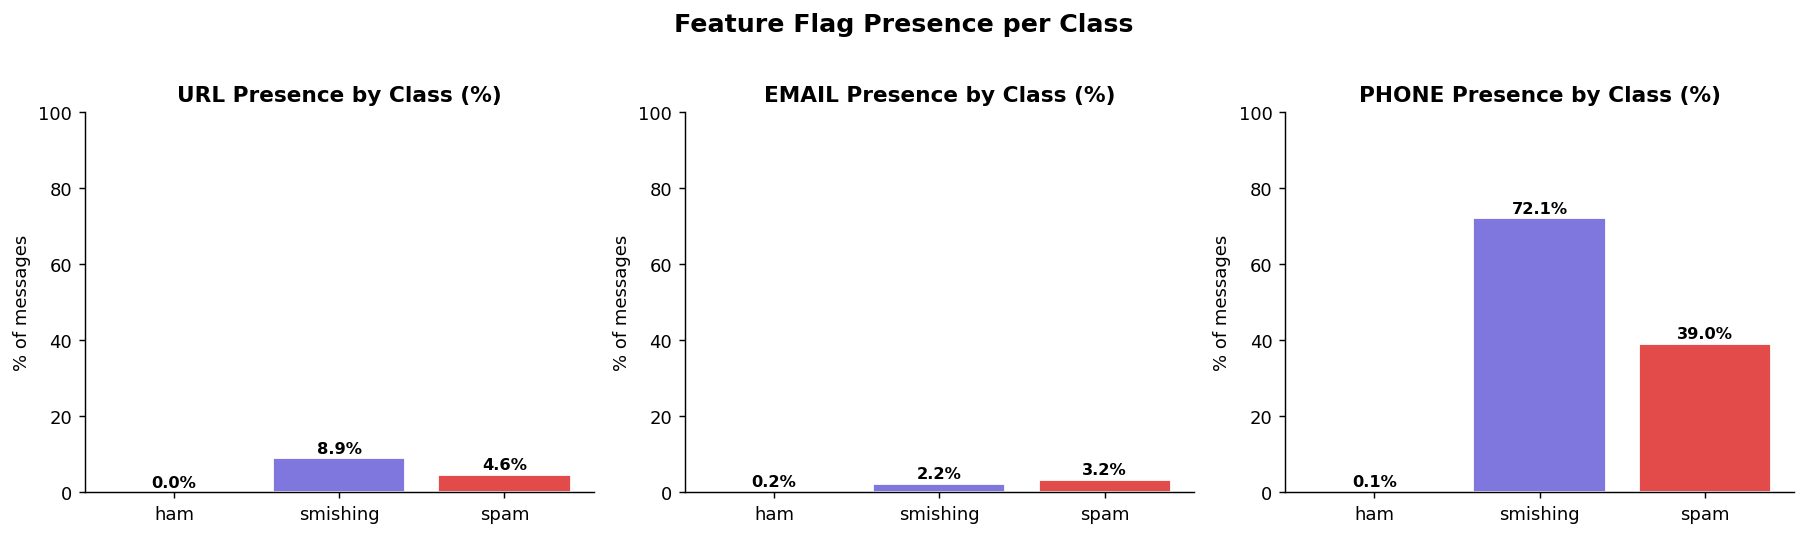

In [4]:
# ── 3.2 URL / Email / Phone flag distribution per class ────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, flag in zip(axes, ['URL', 'EMAIL', 'PHONE']):
    flag_data = df.groupby('label')[flag].mean() * 100
    bar_cols   = [COLORS[l] for l in flag_data.index]
    ax.bar(flag_data.index, flag_data.values, color=bar_cols, edgecolor='white')
    ax.set_title(f'{flag} Presence by Class (%)', fontweight='bold')
    ax.set_ylabel('% of messages')
    ax.set_ylim(0, 100)
    for i, v in enumerate(flag_data.values):
        ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Feature Flag Presence per Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_02_flag_distribution.png', bbox_inches='tight')
plt.show()


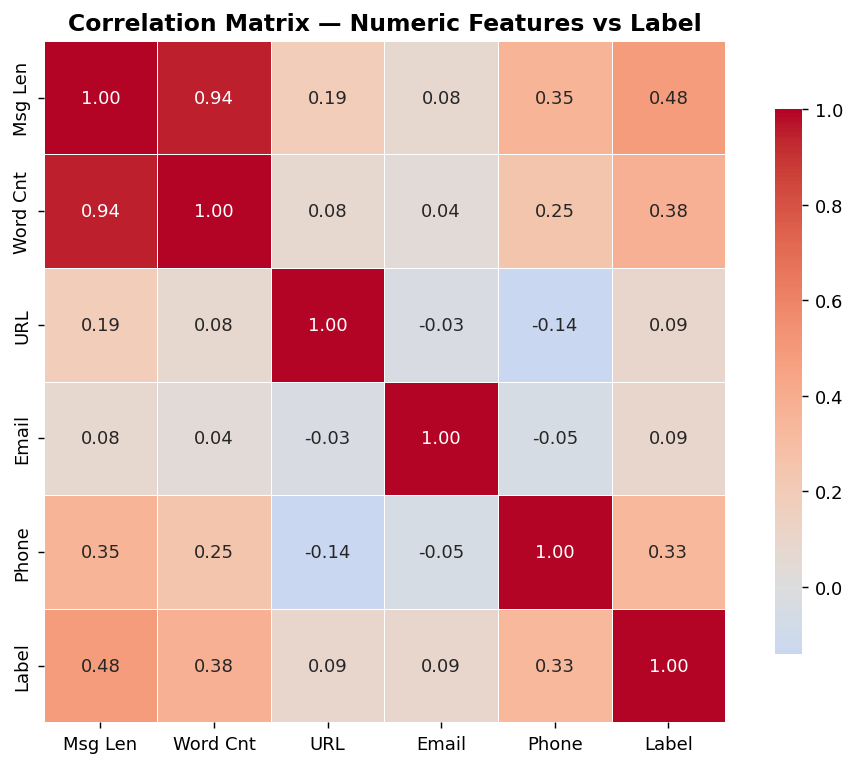

Insight: URL presence is strongly correlated with smishing/spam. Message length varies across classes.


In [5]:
# ── 3.3 Correlation Matrix (numeric features) ────────────────────
numeric_cols = ['msg_len', 'word_count', 'URL', 'EMAIL', 'PHONE']

# Encode label for correlation
le_corr = LabelEncoder()
df['label_enc'] = le_corr.fit_transform(df['label'])   # ham=0, smishing=1, spam=2

corr = df[numeric_cols + ['label_enc']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False   # show full matrix

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, square=True,
            xticklabels=['Msg Len', 'Word Cnt', 'URL', 'Email', 'Phone', 'Label'],
            yticklabels=['Msg Len', 'Word Cnt', 'URL', 'Email', 'Phone', 'Label'],
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features vs Label', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_03_correlation_matrix.png', bbox_inches='tight')
plt.show()
print("Insight: URL presence is strongly correlated with smishing/spam. Message length varies across classes.")


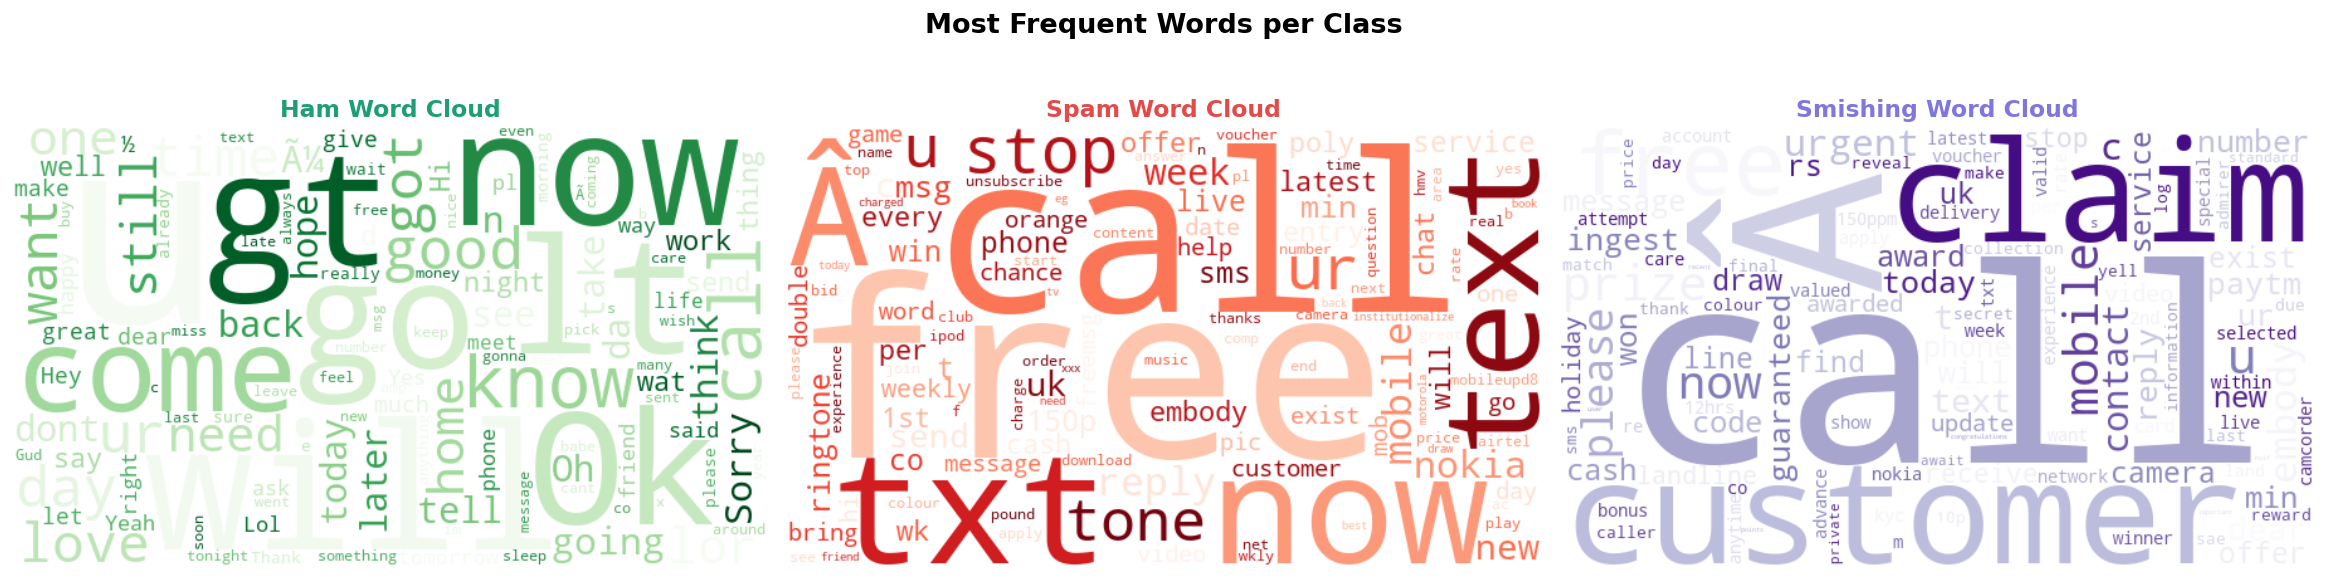

In [6]:
# ── 3.4 Word Clouds — one per class ──────────────────────────────
cmaps = {'ham': 'Greens', 'spam': 'Reds', 'smishing': 'Purples'}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, cmap) in zip(axes, cmaps.items()):
    texts = ' '.join(df[df['label'] == label]['text'].astype(str).values)
    wc = WordCloud(width=600, height=350, background_color='white',
                   colormap=cmap, max_words=120, collocations=False).generate(texts)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{label.capitalize()} Word Cloud', fontweight='bold', fontsize=13,
                 color=COLORS[label])
    ax.axis('off')

plt.suptitle('Most Frequent Words per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_wordclouds.png', bbox_inches='tight')
plt.show()


## 4. Text Preprocessing

Steps applied to every message:
1. Lowercase normalisation
2. Replace URLs → `urllink`
3. Replace emails → `emailaddr`
4. Replace phone numbers → `phonenumber`
5. Remove punctuation & special chars
6. Replace digits → `numbr`
7. Remove stopwords
8. Simple suffix stemming


In [7]:
STOPWORDS = set([
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','he','him','his','himself','she','her','hers','herself','it',
    'its','itself','they','them','their','theirs','themselves','what','which',
    'who','whom','this','that','these','those','am','is','are','was','were',
    'be','been','being','have','has','had','having','do','does','did','doing',
    'a','an','the','and','but','if','or','because','as','until','while','of',
    'at','by','for','with','about','against','between','into','through','during',
    'before','after','above','below','to','from','up','down','in','out','on',
    'off','over','under','again','further','then','once','here','there','when',
    'where','why','how','all','both','each','few','more','most','other','some',
    'such','no','nor','not','only','own','same','so','than','too','very','s',
    't','can','will','just','don','should','now','d','ll','m','o','re','ve',
    'y','ain','aren','couldn','didn','doesn','hadn','hasn','haven','isn','ma',
    'mightn','mustn','needn','shan','shouldn','wasn','weren','won','wouldn'
])

def simple_stem(w):
    for suf in sorted(['ing','tion','tions','ed','ly','er','ers','est','ness',
                       'ment','ments','ful','less','ous','ious','ive','al'], key=len, reverse=True):
        if w.endswith(suf) and len(w)-len(suf) >= 3:
            return w[:-len(suf)]
    if w.endswith('ies') and len(w) > 4: return w[:-3]+'i'
    if w.endswith('es')  and len(w) > 3: return w[:-2]
    if w.endswith('s') and not w.endswith('ss') and len(w) > 3: return w[:-1]
    return w

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' urllink ', text)
    text = re.sub(r'\S+@\S+', ' emailaddr ', text)
    text = re.sub(r'\b\d[\d\s\-\.()]{6,}\d\b', ' phonenumber ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\b\d+\b', ' numbr ', text)
    tokens = [simple_stem(t) for t in text.split()
              if t not in STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

df['text_clean'] = df['text'].apply(preprocess)
print("✅ Preprocessing done.")
print()
for i in range(3):
    print(f"[{df['label'][i].upper()}]  Before: {df['text'][i][:80]}")
    print(f"             After : {df['text_clean'][i][:80]}")
    print()


✅ Preprocessing done.

[HAM]  Before: Hi! You just spoke to DEEPAK. We'd like to know if you were satisfied with the e
             After : hi spoke deepak like know satisfi experience rep toll free yes

[HAM]  Before: Yay can't wait to party together!
             After : yay wait party togeth

[HAM]  Before: At what time are you coming.
             After : time com



## 5. Feature Extraction

**Hybrid feature matrix** combining two sources:
- **TF-IDF** (5,000 features, unigrams + bigrams) — captures textual patterns
- **Binary flags** (3 features: URL, EMAIL, PHONE) — structural signals

Total: **5,003 features** per message.


In [ ]:
# ── 5. Feature Extraction ─────────────────────────────────────────────────

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                         min_df=2, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df['text_clean'])

# Structural flags (original)
X_flags = sp.csr_matrix(df[['URL', 'EMAIL', 'PHONE']].values)

# ── Smishing-specific features ────────────────────────────────────────────
SMISHING_BRANDS = [
    'paypal','barclays','hsbc','lloyds','natwest','halifax','bank',
    'usps','fedex','ups','dhl','amazon','apple','microsoft','netflix',
    'vodafone','o2','gov','hmrc','irs','dvla','nhs','santander'
]
SMISHING_KW = [
    'suspended','blocked','verify','confirm','unauthorized',
    'locked','expire','validate','action required',
    'security alert','login attempt','update your','restore access',
    'compromised','credential','account has been'
]
SPAM_ONLY_KW = [
    'winner','won','prize','reward','free gift','cashback','discount',
    'percent off','buy now','limited offer','click to claim',
    'you have won','congratulations','selected to receive',
    'claim your','claim now','free entry','txt to win',
    'lottery','jackpot','bonus','£','cash'
]

def smishing_features(text):
    t = str(text).lower()
    has_url    = int(bool(re.search(r'http\S+|www\.\S+|bit\.ly|tinyurl', t)))
    has_brand  = int(any(b in t for b in SMISHING_BRANDS))
    has_smish  = int(any(k in t for k in SMISHING_KW))
    has_spam   = int(any(k in t for k in SPAM_ONLY_KW))
    brand_url  = has_brand * has_url
    smish_url  = has_smish * has_url
    pure_spam  = has_spam  * (1 - has_url) * (1 - has_brand)
    pure_smish = has_smish * (1 - has_spam)
    urgency    = min(sum(1 for k in ['urgent','immediately','24 hour','48 hour','asap'] if k in t), 3)
    return [has_url, has_brand, has_smish, has_spam,
            brand_url, smish_url, pure_spam, pure_smish, urgency]

X_smishing_feats = sp.csr_matrix(
    np.array([smishing_features(t) for t in df['text']], dtype=float)
)

# Combined: TF-IDF + original flags + smishing-specific features = 5,012 features
X = sp.hstack([X_tfidf, X_flags, X_smishing_feats], format='csr')

# Encode labels
le = LabelEncoder()
y  = le.fit_transform(df['label'])
CLASS_NAMES = le.classes_.tolist()   # ['ham', 'smishing', 'spam']

feature_names = np.array(
    list(tfidf.get_feature_names_out()) +
    ['flag_URL', 'flag_EMAIL', 'flag_PHONE',
     'sf_url', 'sf_brand', 'sf_smish_kw', 'sf_spam_kw',
     'sf_brand_url', 'sf_smish_url', 'sf_pure_spam', 'sf_pure_smish', 'sf_urgency']
)

print("Feature matrix shape :", X.shape)   # (10191, 5012)
print("Classes              :", CLASS_NAMES)
print("Label encoding       :", {c: i for i, c in enumerate(CLASS_NAMES)})
print()

# Top discriminating words per class
spam_mask  = y == CLASS_NAMES.index('spam')
ham_mask   = y == CLASS_NAMES.index('ham')
smish_mask = y == CLASS_NAMES.index('smishing')
spam_mean  = np.asarray(X_tfidf[spam_mask].mean(axis=0)).flatten()
ham_mean   = np.asarray(X_tfidf[ham_mask].mean(axis=0)).flatten()
smish_mean = np.asarray(X_tfidf[smish_mask].mean(axis=0)).flatten()
fn         = np.array(tfidf.get_feature_names_out())
print("Top spam words    :", fn[np.argsort(spam_mean - ham_mean)[::-1][:10]].tolist())
print("Top smishing words:", fn[np.argsort(smish_mean - spam_mean)[::-1][:10]].tolist())

Feature matrix shape : (10191, 5011)
Classes              : ['ham', 'smishing', 'spam']
Label encoding       : {'ham': 0, 'smishing': 1, 'spam': 2}

Top spam words    : ['numbr', 'free', 'txt', 'phonenumb', 'numbr numbr', 'stop', 'urllink', 'text', 'week', 'nokia']
Top smishing words: ['call phonenumb', 'call', 'phonenumb', 'prize', 'claim', 'custom', 'urgent', 'please', 'award', 'contact']


## 6. Train / Test Split (80 / 20, Stratified)

Training  : 8,152 samples
Testing   : 2,039 samples

  ham        → train 2718  test 679
  smishing   → train 2717  test 680
  spam       → train 2717  test 680


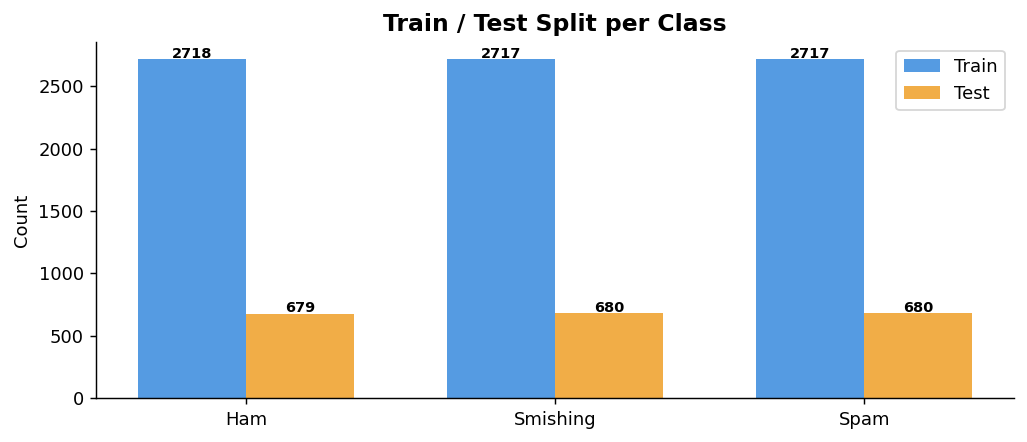

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training  : {X_train.shape[0]:,} samples")
print(f"Testing   : {X_test.shape[0]:,} samples")
print()
for i, cls in enumerate(CLASS_NAMES):
    tr = (y_train==i).sum()
    te = (y_test ==i).sum()
    print(f"  {cls:10s} → train {tr}  test {te}")

# Visualise
fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(CLASS_NAMES))
w = 0.35
tr_c = [(y_train==i).sum() for i in range(len(CLASS_NAMES))]
te_c = [(y_test ==i).sum() for i in range(len(CLASS_NAMES))]
ax.bar(x - w/2, tr_c, w, label='Train', color='#378ADD', alpha=0.85)
ax.bar(x + w/2, te_c, w, label='Test',  color='#EF9F27', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([c.capitalize() for c in CLASS_NAMES])
ax.set_title('Train / Test Split per Class', fontweight='bold', fontsize=13)
ax.set_ylabel('Count'); ax.legend()
for xi, tv, ev in zip(x, tr_c, te_c):
    ax.text(xi-w/2, tv+10, str(tv), ha='center', fontsize=8, fontweight='bold')
    ax.text(xi+w/2, ev+10, str(ev), ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_split.png', bbox_inches='tight')
plt.show()


## 7. Train All 7 Models

### Anti-Overfitting Measures Applied
| Algorithm | Technique |
|-----------|-----------|
| Naive Bayes | `alpha=0.5` (Laplace smoothing) |
| Logistic Regression | `C=0.5` (stronger L2 regularisation) |
| SVM | `C=0.5` (wider margin) |
| Random Forest | `max_depth=20`, `min_samples_leaf=3` |
| KNN | `n_neighbors=11` (more neighbours = smoother boundary) |
| XGBoost | `max_depth=5`, `subsample=0.8`, `colsample_bytree=0.8` |
| Decision Tree | `max_depth=12`, `min_samples_leaf=5`, `ccp_alpha=0.0001` |


In [10]:
nb_model  = MultinomialNB(alpha=0.5)
lr_model  = LogisticRegression(C=0.5, max_iter=1000, random_state=42,
                                multi_class='multinomial', solver='lbfgs')
svm_base  = LinearSVC(C=0.5, max_iter=3000, random_state=42)
svm_model = CalibratedClassifierCV(svm_base)
rf_model  = RandomForestClassifier(n_estimators=200, max_depth=20,
                                    min_samples_leaf=3, random_state=42, n_jobs=-1)
knn_model = KNeighborsClassifier(n_neighbors=11, metric='cosine', n_jobs=-1)
xgb_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8,
                           eval_metric='mlogloss', random_state=42, n_jobs=-1)
dt_model  = DecisionTreeClassifier(max_depth=12, min_samples_leaf=5,
                                    ccp_alpha=0.0001, random_state=42)

trained_models = [
    ('Naive Bayes',         nb_model),
    ('Logistic Regression', lr_model),
    ('SVM',                 svm_model),
    ('Random Forest',       rf_model),
    ('KNN',                 knn_model),
    ('XGBoost',             xgb_model),
    ('Decision Tree',       dt_model),
]

for name, model in trained_models:
    model.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, model.predict(X_train)) * 100
    te_acc = accuracy_score(y_test,  model.predict(X_test))  * 100
    print(f"  {name:22s}  Train: {tr_acc:.2f}%  Test: {te_acc:.2f}%  Gap: {tr_acc-te_acc:.2f}%")

print("\n✅ All 7 models trained.")


  Naive Bayes             Train: 94.63%  Test: 92.74%  Gap: 1.89%
  Logistic Regression     Train: 96.98%  Test: 95.83%  Gap: 1.15%
  SVM                     Train: 98.21%  Test: 97.30%  Gap: 0.91%
  Random Forest           Train: 93.92%  Test: 91.76%  Gap: 2.15%
  KNN                     Train: 96.34%  Test: 93.77%  Gap: 2.57%
  XGBoost                 Train: 98.71%  Test: 96.86%  Gap: 1.85%
  Decision Tree           Train: 92.38%  Test: 90.58%  Gap: 1.80%

✅ All 7 models trained.


## 8. Model Evaluation & Comparison

In [11]:
results = {}
models_info = [
    ('Naive Bayes',         nb_model),
    ('Logistic Regression', lr_model),
    ('SVM',                 svm_model),
    ('Random Forest',       rf_model),
    ('KNN',                 knn_model),
    ('XGBoost',             xgb_model),
    ('Decision Tree',       dt_model),
]

for name, model in models_info:
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)
    results[name] = {
        'Accuracy':  round(accuracy_score (y_test, pred)*100, 2),
        'Precision': round(precision_score(y_test, pred, average='weighted')*100, 2),
        'Recall':    round(recall_score   (y_test, pred, average='weighted')*100, 2),
        'F1 Score':  round(f1_score       (y_test, pred, average='weighted')*100, 2),
        'AUC-ROC':   round(roc_auc_score  (y_test, prob, multi_class='ovr', average='weighted')*100, 2),
    }

results_df = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
print("── Model Comparison (weighted avg) ─────────────────────────────")
print(results_df.to_string())


── Model Comparison (weighted avg) ─────────────────────────────
                     Accuracy  Precision  Recall  F1 Score  AUC-ROC
SVM                     97.30      97.31   97.30     97.30    99.86
XGBoost                 96.86      96.87   96.86     96.86    99.76
Logistic Regression     95.83      95.83   95.83     95.83    99.58
KNN                     93.77      93.76   93.77     93.75    99.29
Naive Bayes             92.74      92.74   92.74     92.73    98.71
Random Forest           91.76      92.21   91.76     91.70    98.97
Decision Tree           90.58      90.54   90.58     90.47    96.74


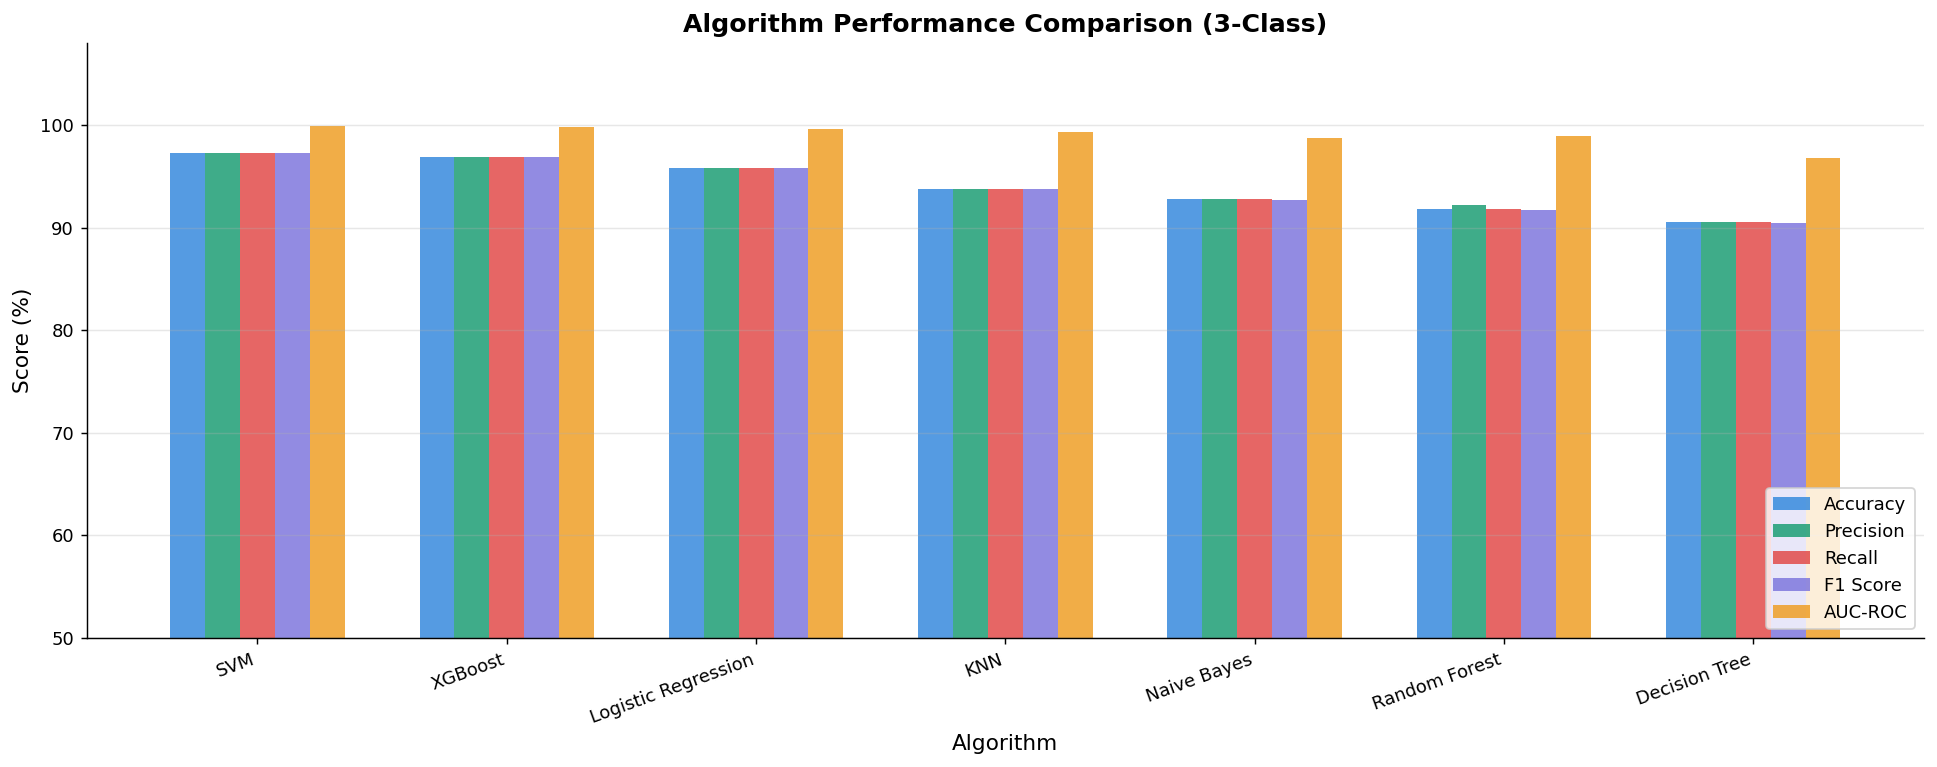

In [12]:
metrics     = ['Accuracy','Precision','Recall','F1 Score','AUC-ROC']
model_names = results_df.index.tolist()
x = np.arange(len(model_names))
width = 0.14
colors_m = ['#378ADD','#1D9E75','#E24B4A','#7F77DD','#EF9F27']

fig, ax = plt.subplots(figsize=(15, 6))
for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    vals = results_df[metric].values
    ax.bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85)

ax.set_xlabel('Algorithm', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Algorithm Performance Comparison (3-Class)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width*2); ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylim(50, 108); ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_06_model_comparison.png', bbox_inches='tight')
plt.show()


In [13]:
for name, model in models_info:
    pred = model.predict(X_test)
    print(f"{'='*55}\n{name}")
    print(classification_report(y_test, pred,
          target_names=[c.capitalize() for c in CLASS_NAMES]))


Naive Bayes
              precision    recall  f1-score   support

         Ham       0.97      0.97      0.97       679
    Smishing       0.91      0.93      0.92       680
        Spam       0.91      0.89      0.90       680

    accuracy                           0.93      2039
   macro avg       0.93      0.93      0.93      2039
weighted avg       0.93      0.93      0.93      2039

Logistic Regression
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       679
    Smishing       0.95      0.95      0.95       680
        Spam       0.94      0.94      0.94       680

    accuracy                           0.96      2039
   macro avg       0.96      0.96      0.96      2039
weighted avg       0.96      0.96      0.96      2039

SVM
              precision    recall  f1-score   support

         Ham       1.00      0.99      0.99       679
    Smishing       0.97      0.96      0.96       680
        Spam       0.96      0.97      

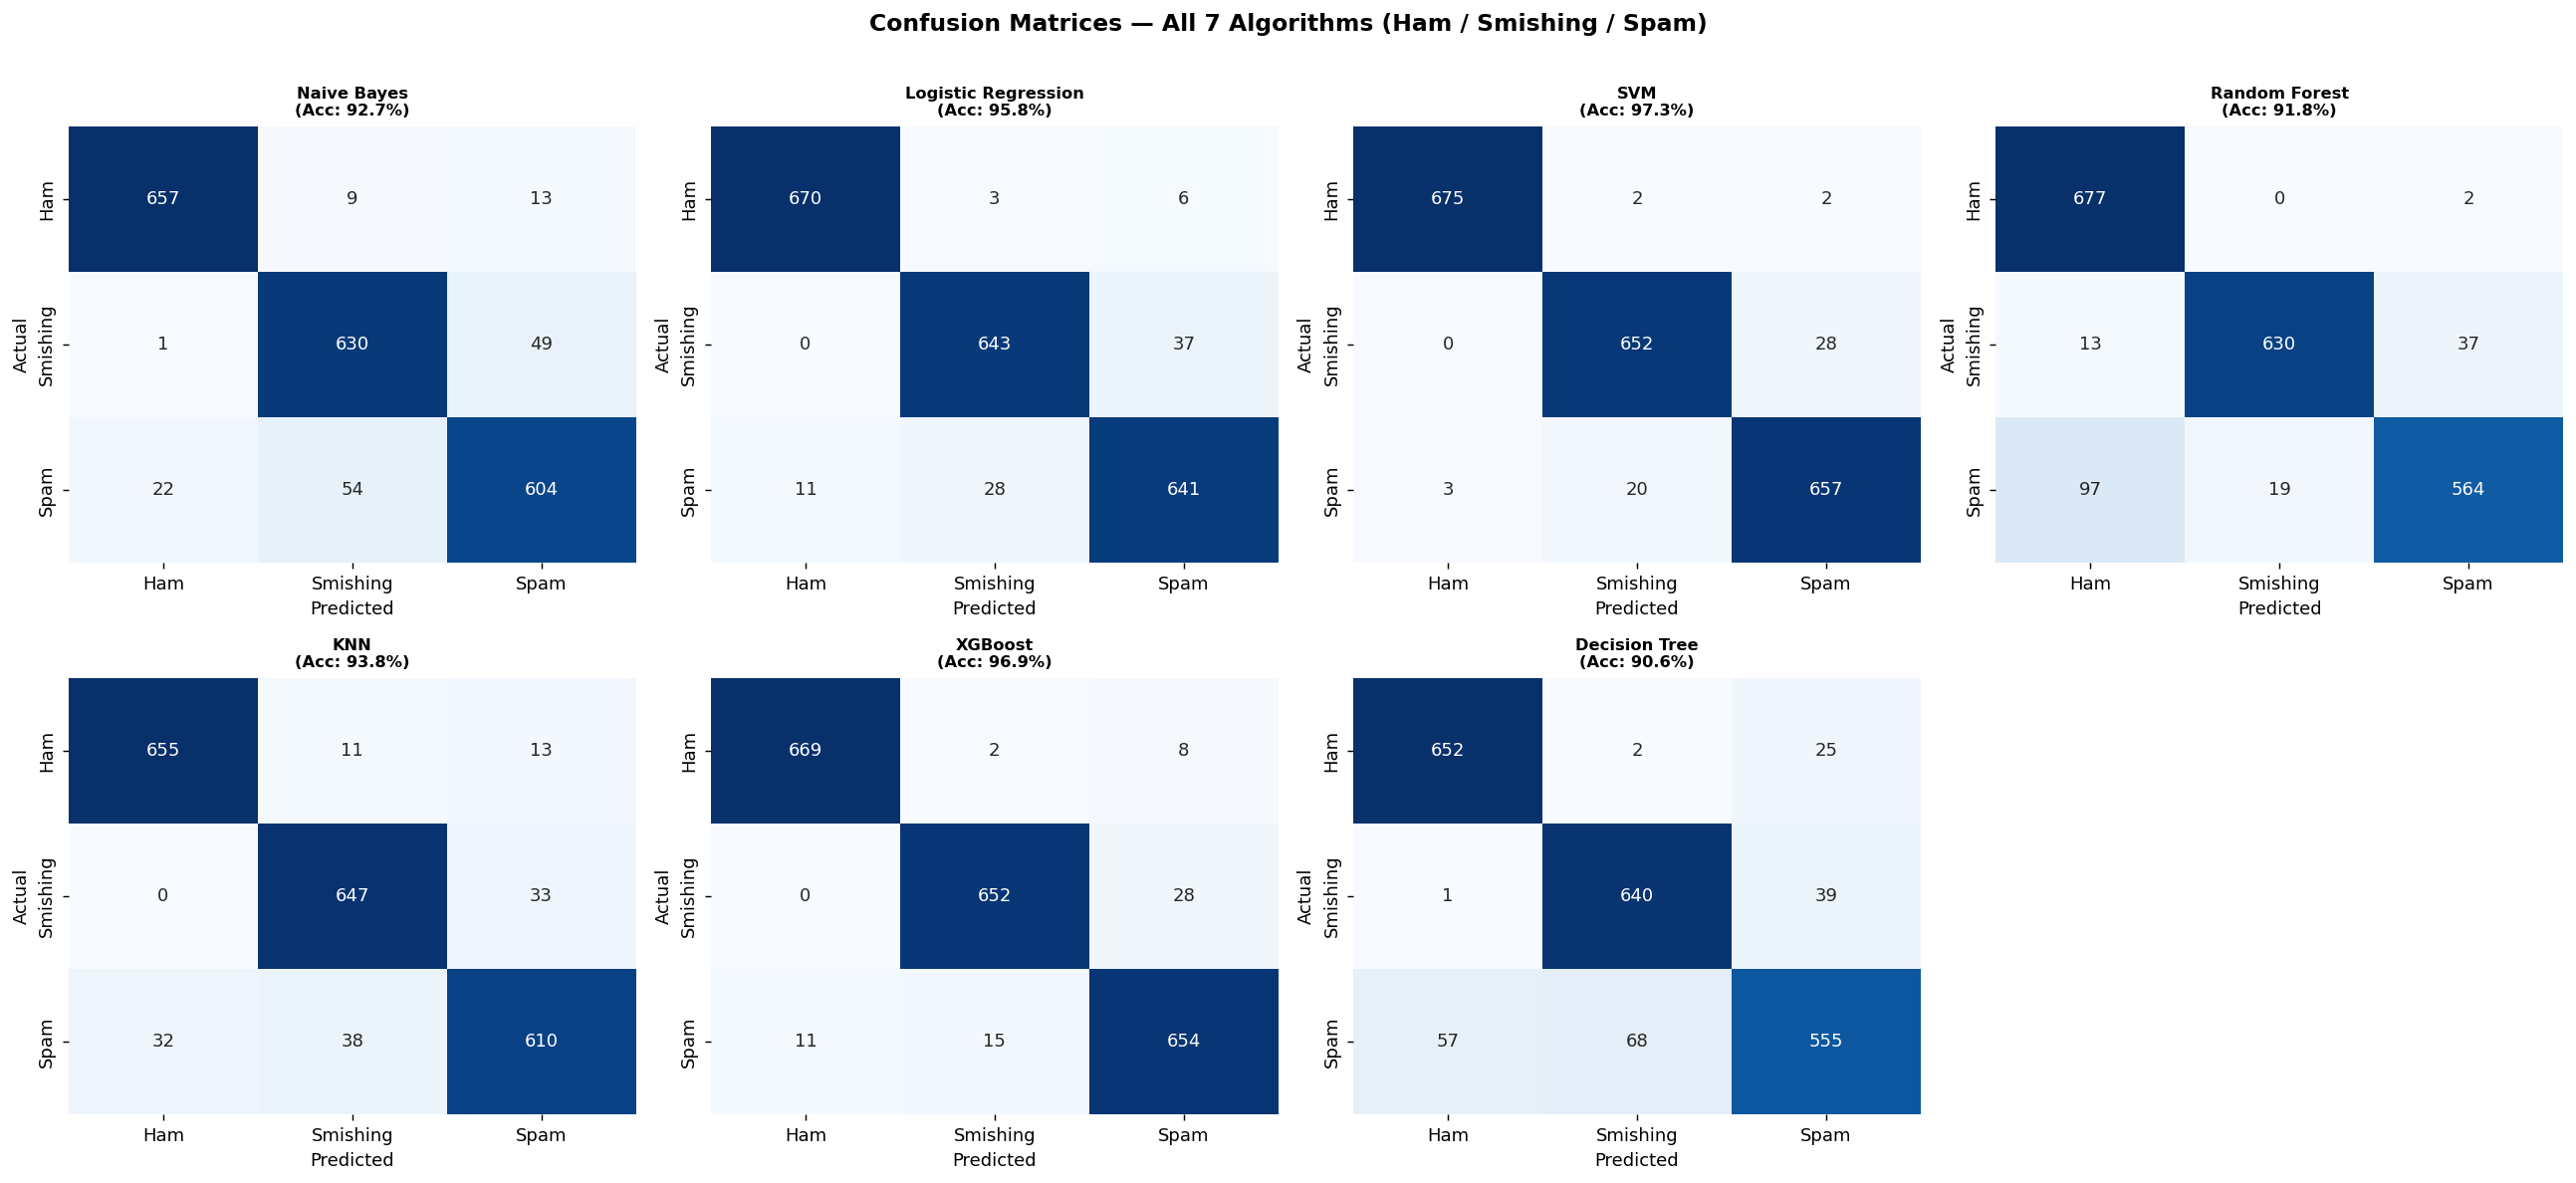

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
labels_cap = [c.capitalize() for c in CLASS_NAMES]

for idx, (name, model) in enumerate(models_info):
    pred = model.predict(X_test)
    cm   = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues',
                cbar=False, xticklabels=labels_cap, yticklabels=labels_cap)
    acc = accuracy_score(y_test, pred)*100
    axes[idx].set_title(f'{name}\n(Acc: {acc:.1f}%)', fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')

axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All 7 Algorithms (Ham / Smishing / Spam)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_07_confusion_matrices.png', bbox_inches='tight')
plt.show()


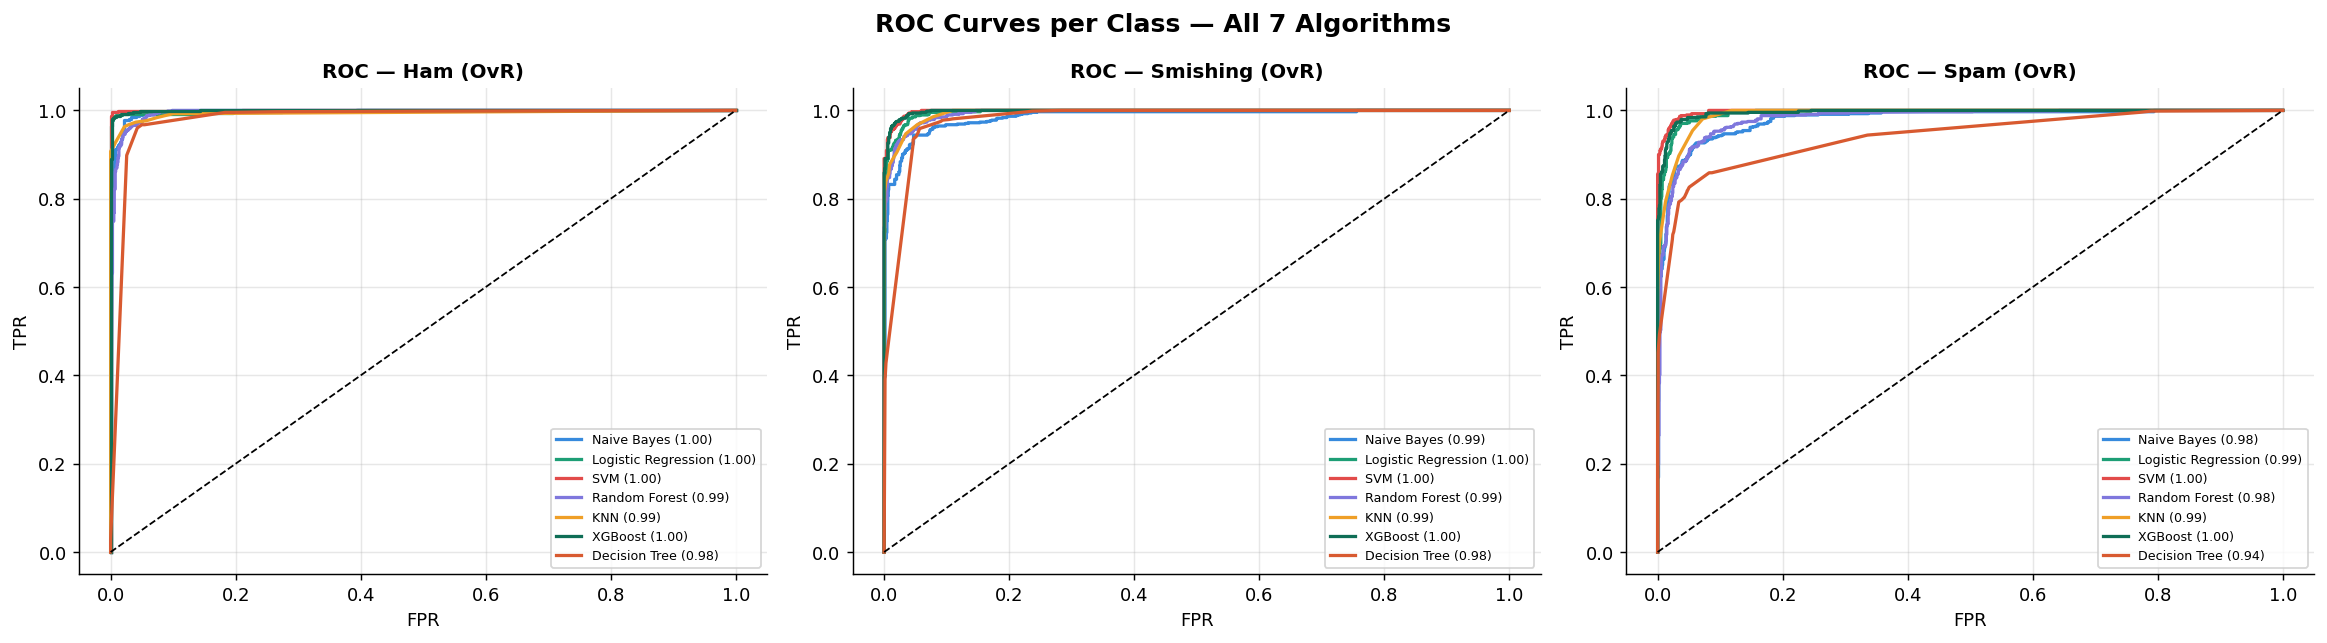

In [15]:
roc_colors = ['#378ADD','#1D9E75','#E24B4A','#7F77DD','#EF9F27','#0F6E56','#D85A30']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = [c.capitalize() for c in CLASS_NAMES]

for cls_idx, (ax, cls_name) in enumerate(zip(axes, class_labels)):
    for (name, model), color in zip(models_info, roc_colors):
        prob  = model.predict_proba(X_test)[:, cls_idx]
        y_bin = (y_test == cls_idx).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, prob)
        auc = roc_auc_score(y_bin, prob)
        ax.plot(fpr, tpr, label=f'{name} ({auc:.2f})', color=color, lw=1.8)
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(f'ROC — {cls_name} (OvR)', fontweight='bold', fontsize=11)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=7, loc='lower right'); ax.grid(alpha=0.3)

plt.suptitle('ROC Curves per Class — All 7 Algorithms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_08_roc_curves.png', bbox_inches='tight')
plt.show()


## 9. Overfitting Detection & Learning Curves

We compare **Train vs Test accuracy** and plot **learning curves** to diagnose overfitting.
A gap > 5% or diverging curves signals a model memorising the training set.


In [16]:
print(f"{'Model':<22} {'Train':>9} {'Test':>8} {'Gap':>7}  Status")
print("-"*60)
gap_data = {}
for name, model in models_info:
    tr  = accuracy_score(y_train, model.predict(X_train)) * 100
    te  = accuracy_score(y_test,  model.predict(X_test))  * 100
    gap = tr - te
    gap_data[name] = {'train': tr, 'test': te, 'gap': gap}
    status = "OVERFIT" if gap > 5 else "OK"
    print(f"{name:<22} {tr:>9.2f}% {te:>7.2f}% {gap:>6.2f}%  {status}")


Model                      Train     Test     Gap  Status
------------------------------------------------------------
Naive Bayes                94.63%   92.74%   1.89%  OK
Logistic Regression        96.98%   95.83%   1.15%  OK
SVM                        98.21%   97.30%   0.91%  OK
Random Forest              93.92%   91.76%   2.15%  OK
KNN                        96.34%   93.77%   2.57%  OK
XGBoost                    98.71%   96.86%   1.85%  OK
Decision Tree              92.38%   90.58%   1.80%  OK


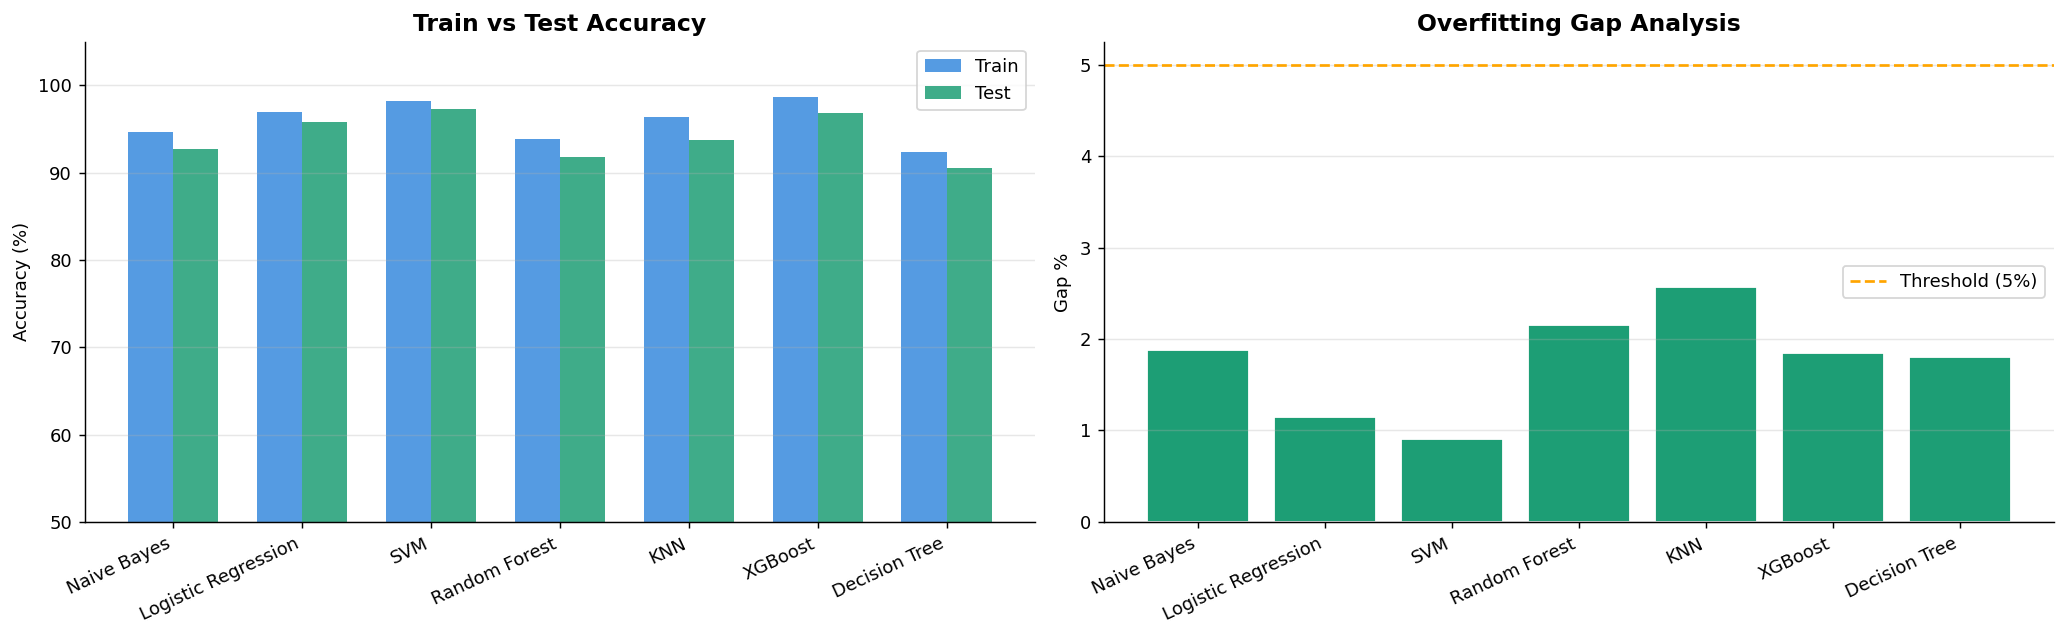

In [17]:
names  = list(gap_data.keys())
trains = [gap_data[n]['train'] for n in names]
tests  = [gap_data[n]['test']  for n in names]
gaps   = [gap_data[n]['gap']   for n in names]

x = np.arange(len(names)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(x-w/2, trains, w, label='Train', color='#378ADD', alpha=0.85)
axes[0].bar(x+w/2, tests,  w, label='Test',  color='#1D9E75', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=25, ha='right')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(50, 105)
axes[0].set_title('Train vs Test Accuracy', fontweight='bold', fontsize=13)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

gap_colors = ['#E24B4A' if g > 5 else '#1D9E75' for g in gaps]
axes[1].bar(names, gaps, color=gap_colors, edgecolor='white')
axes[1].axhline(5, color='orange', linestyle='--', lw=1.5, label='Threshold (5%)')
axes[1].set_xticks(range(len(names))); axes[1].set_xticklabels(names, rotation=25, ha='right')
axes[1].set_ylabel('Gap %'); axes[1].set_title('Overfitting Gap Analysis', fontweight='bold', fontsize=13)
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_09_overfitting.png', bbox_inches='tight')
plt.show()


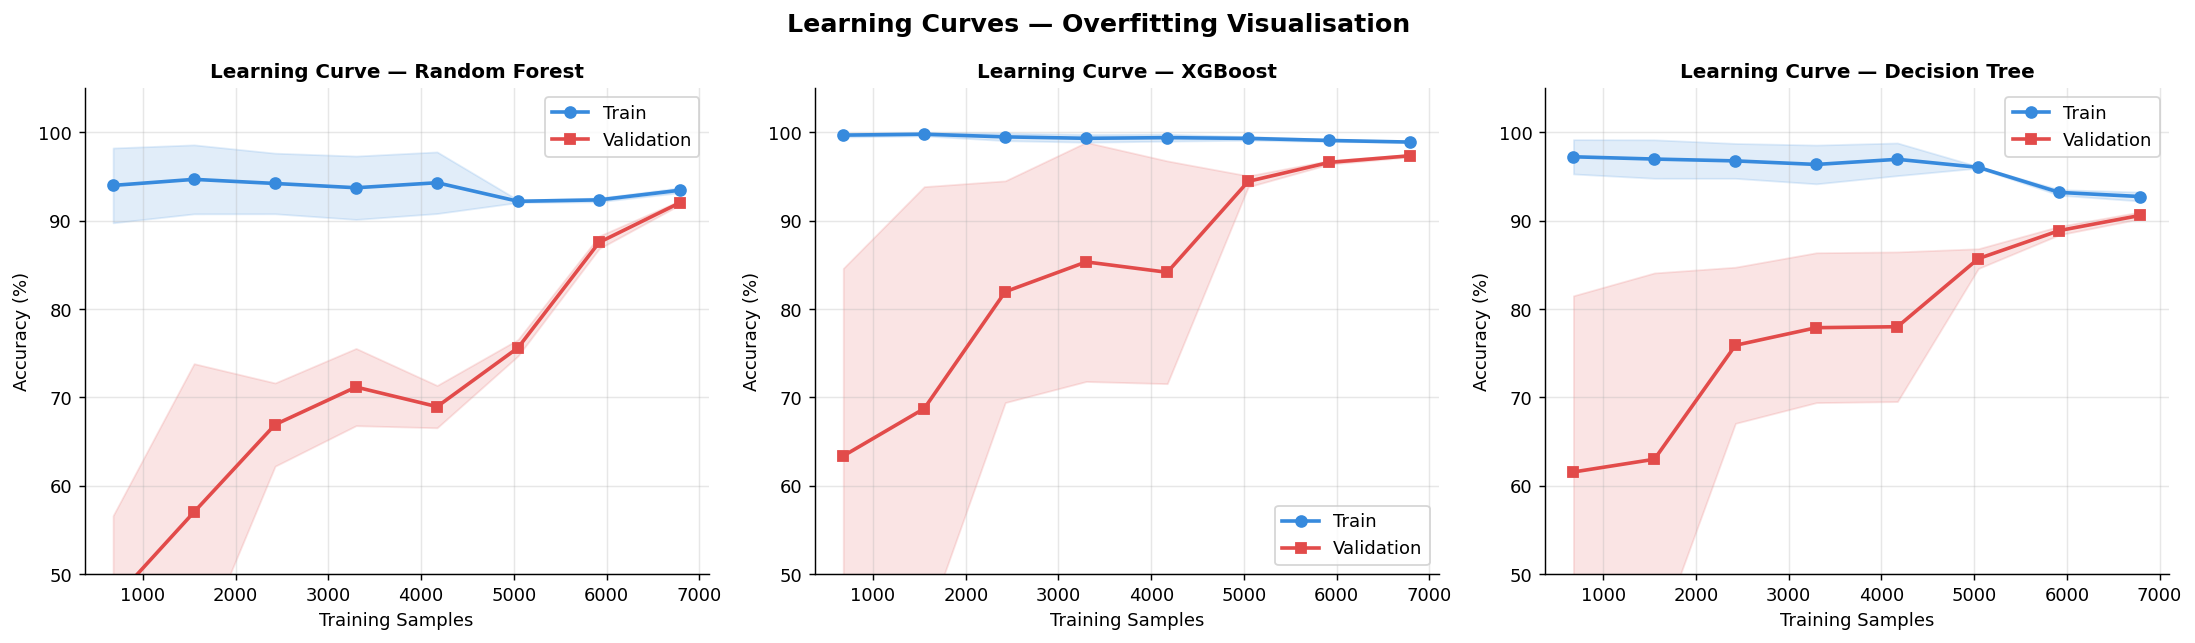

In [18]:
from sklearn.model_selection import learning_curve

lc_models = [
    ('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=20,
                       min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ('XGBoost',       XGBClassifier(n_estimators=100, max_depth=5,
                       eval_metric='mlogloss', random_state=42, n_jobs=-1)),
    ('Decision Tree', DecisionTreeClassifier(max_depth=12, min_samples_leaf=5,
                       ccp_alpha=0.0001, random_state=42)),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
train_sizes = np.linspace(0.1, 1.0, 8)

for ax, (name, model) in zip(axes, lc_models):
    ts, tr_sc, val_sc = learning_curve(model, X, y, train_sizes=train_sizes,
                                        cv=3, scoring='accuracy', n_jobs=-1)
    tr_m  = tr_sc.mean(axis=1)*100;  val_m = val_sc.mean(axis=1)*100
    tr_s  = tr_sc.std(axis=1)*100;   val_s = val_sc.std(axis=1)*100
    ax.plot(ts, tr_m,  'o-', color='#378ADD', label='Train',      lw=2)
    ax.plot(ts, val_m, 's-', color='#E24B4A', label='Validation', lw=2)
    ax.fill_between(ts, tr_m-tr_s,  tr_m+tr_s,  alpha=0.15, color='#378ADD')
    ax.fill_between(ts, val_m-val_s,val_m+val_s, alpha=0.15, color='#E24B4A')
    ax.set_title(f'Learning Curve — {name}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Training Samples'); ax.set_ylabel('Accuracy (%)')
    ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(50, 105)

plt.suptitle('Learning Curves — Overfitting Visualisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_10_learning_curves.png', bbox_inches='tight')
plt.show()


## 10. 5-Fold Stratified Cross-Validation

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = [
    ('Naive Bayes',         MultinomialNB(alpha=0.5)),
    ('Logistic Regression', LogisticRegression(C=0.5, max_iter=1000, random_state=42)),
    ('SVM',                 CalibratedClassifierCV(LinearSVC(C=0.5, max_iter=3000, random_state=42))),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, max_depth=20,
                             min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ('KNN',                 KNeighborsClassifier(n_neighbors=11, metric='cosine')),
    ('XGBoost',             XGBClassifier(n_estimators=100, max_depth=5,
                             eval_metric='mlogloss', random_state=42, n_jobs=-1)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=12, min_samples_leaf=5,
                             ccp_alpha=0.0001, random_state=42)),
]

cv_results = {}
print("Running 5-fold cross-validation...")
for name, model in cv_models:
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores * 100
    print(f"  {name:22s}: {scores.mean()*100:.2f}% +/- {scores.std()*100:.2f}%")
print("\n✅ Done.")


Running 5-fold cross-validation...
  Naive Bayes           : 93.34% +/- 0.43%
  Logistic Regression   : 96.20% +/- 0.30%
  SVM                   : 97.57% +/- 0.35%
  Random Forest         : 91.97% +/- 0.50%
  KNN                   : 94.11% +/- 0.50%
  XGBoost               : 97.45% +/- 0.31%
  Decision Tree         : 90.26% +/- 0.87%

✅ Done.


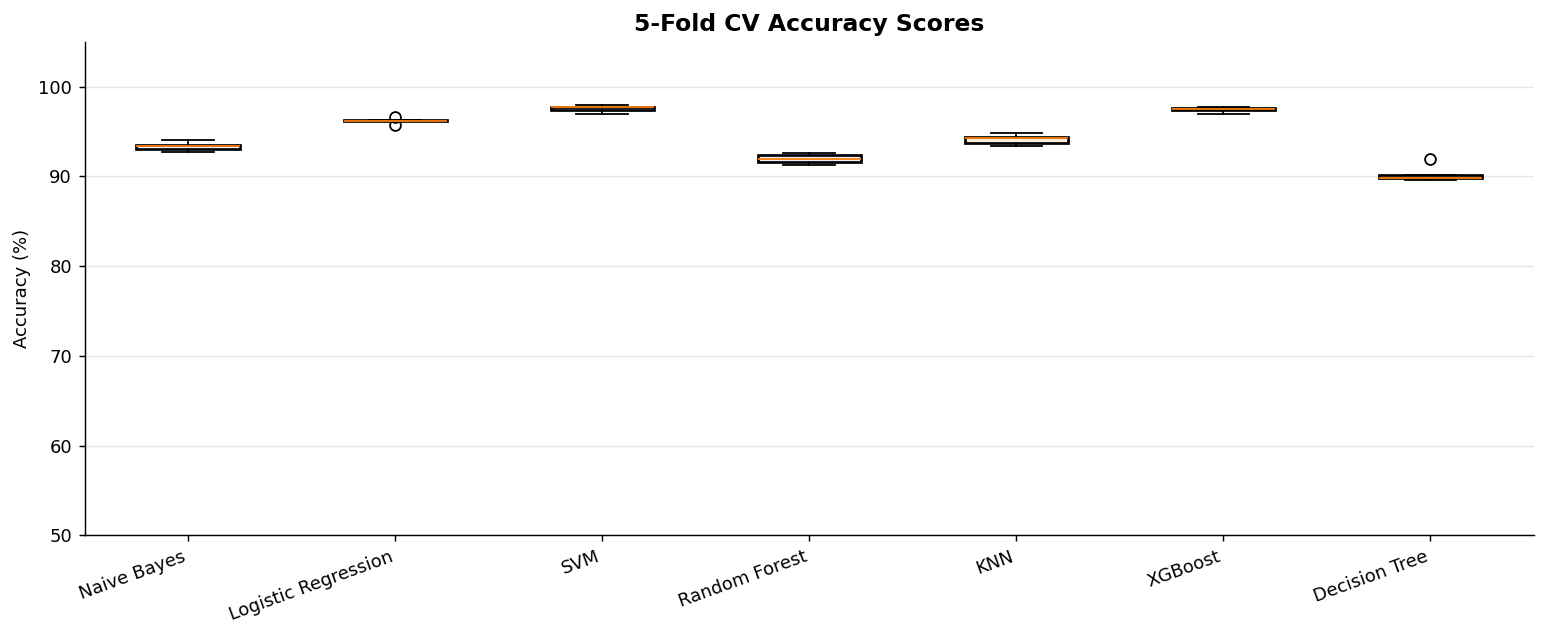

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
names_cv = list(cv_results.keys())
bp = ax.boxplot([cv_results[n] for n in names_cv], patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'],
    ['#E6F1FB','#EAF3DE','#FCEBEB','#EEEDFE','#FAEEDA','#E1F5EE','#FAECE7']):
    patch.set_facecolor(c); patch.set_linewidth(1.5)
ax.set_xticklabels(names_cv, rotation=20, ha='right')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(50, 105)
ax.set_title('5-Fold CV Accuracy Scores', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_11_crossval.png', bbox_inches='tight')
plt.show()


## 11. Feature Importance Analysis

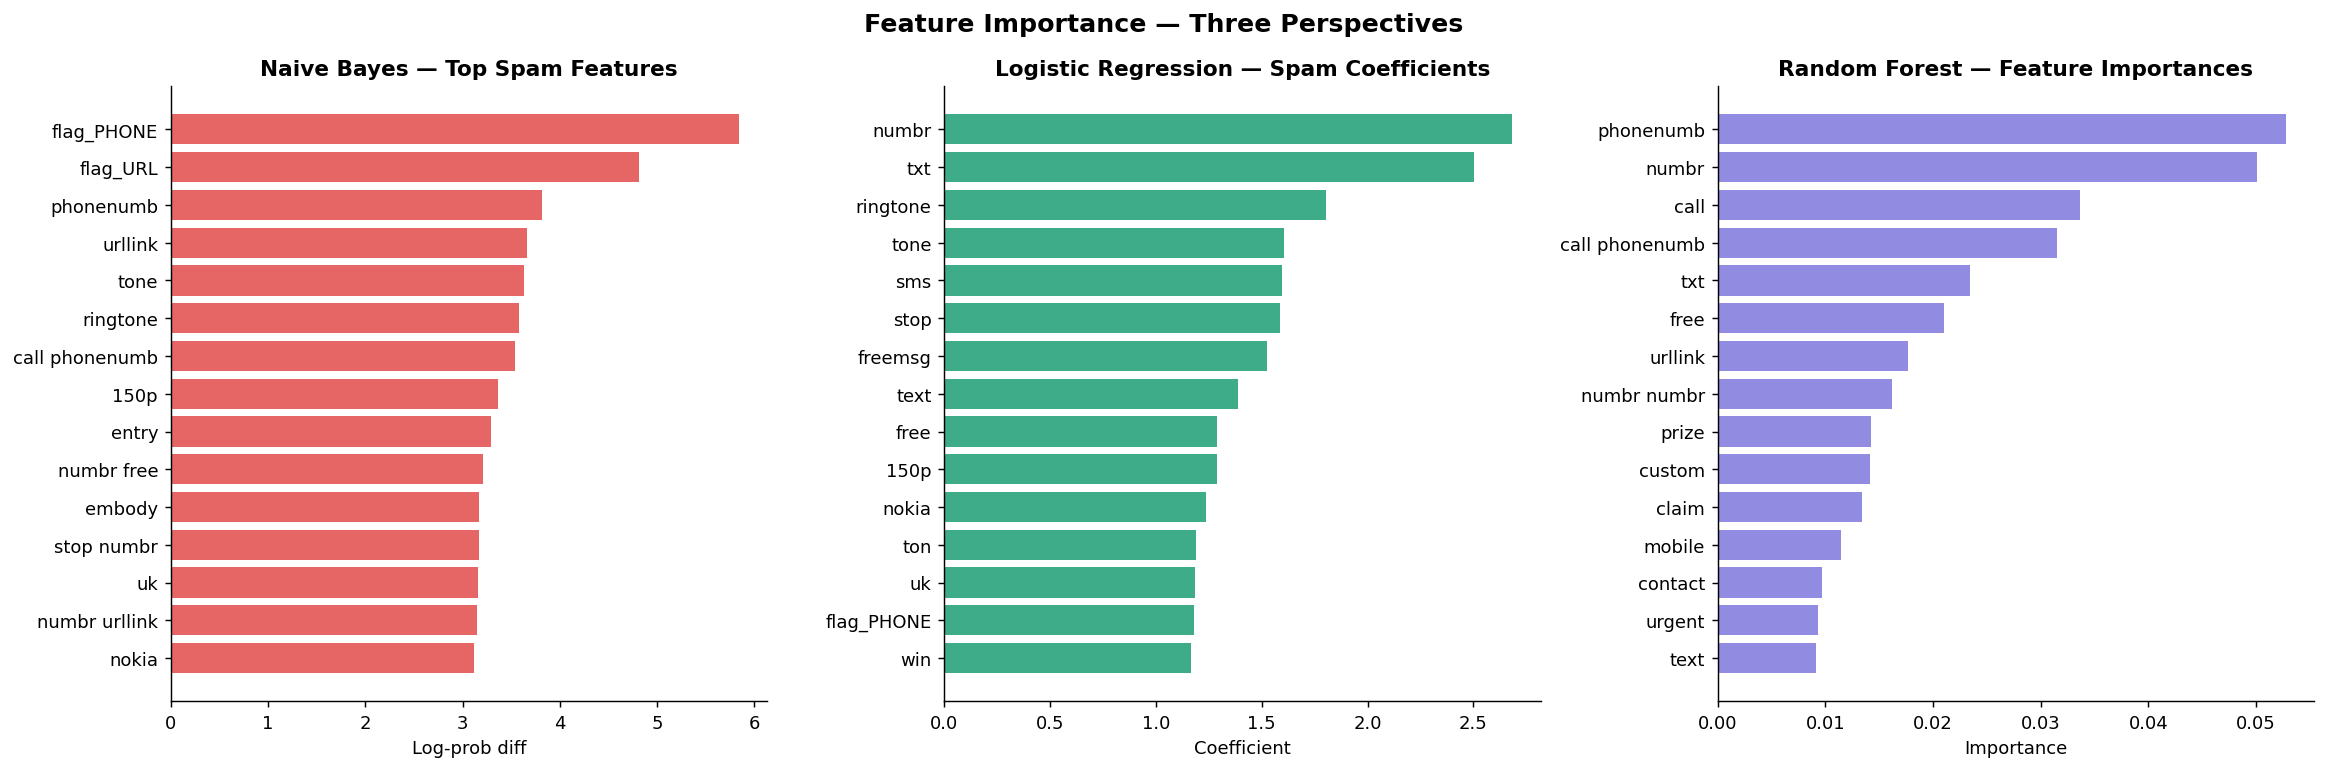

In [ ]:
fn_tfidf = np.array(tfidf.get_feature_names_out())
fn_all   = np.array(
    list(tfidf.get_feature_names_out()) +
    ['flag_URL', 'flag_EMAIL', 'flag_PHONE',
     'sf_url', 'sf_brand', 'sf_smish_kw', 'sf_spam_kw',
     'sf_brand_url', 'sf_smish_url', 'sf_pure_spam', 'sf_pure_smish', 'sf_urgency']
)

spam_idx = CLASS_NAMES.index('spam')
ham_idx  = CLASS_NAMES.index('ham')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# NB log-prob diff — use fn_all (covers all 5012 features)
log_diff = nb_model.feature_log_prob_[spam_idx] - nb_model.feature_log_prob_[ham_idx]
top_nb   = np.argsort(log_diff)[-15:][::-1]
axes[0].barh(fn_all[top_nb][::-1], log_diff[top_nb][::-1], color='#E24B4A', alpha=0.85)
axes[0].set_title('Naive Bayes — Top Spam Features', fontweight='bold')
axes[0].set_xlabel('Log-prob diff')

# LR coefficients — use fn_all (covers all 5012 features)
coef   = lr_model.coef_[spam_idx]
top_lr = np.argsort(coef)[-15:][::-1]
axes[1].barh(fn_all[top_lr][::-1], coef[top_lr][::-1], color='#1D9E75', alpha=0.85)
axes[1].set_title('Logistic Regression — Spam Coefficients', fontweight='bold')
axes[1].set_xlabel('Coefficient')

# RF importances — TF-IDF portion only (first 5000), fn_tfidf is correct here
fi     = rf_model.feature_importances_[:5000]
top_rf = np.argsort(fi)[-15:][::-1]
axes[2].barh(fn_tfidf[top_rf][::-1], fi[top_rf][::-1], color='#7F77DD', alpha=0.85)
axes[2].set_title('Random Forest — Feature Importances', fontweight='bold')
axes[2].set_xlabel('Importance')

plt.suptitle('Feature Importance — Three Perspectives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_12_feature_importance.png', bbox_inches='tight')
plt.show()

## 12. Save Models & Vectorizer

In [22]:
os.makedirs('saved_models', exist_ok=True)
artefacts = {
    'tfidf_vectorizer':         tfidf,
    'label_encoder':            le,
    'model_naive_bayes':        nb_model,
    'model_logistic_regression':lr_model,
    'model_svm':                svm_model,
    'model_random_forest':      rf_model,
    'model_knn':                knn_model,
    'model_xgboost':            xgb_model,
    'model_decision_tree':      dt_model,
}
for fname, obj in artefacts.items():
    pickle.dump(obj, open(f'saved_models/{fname}.pkl', 'wb'))
print("✅ Saved to saved_models/")
print(os.listdir('saved_models'))


✅ Saved to saved_models/
['label_encoder.pkl', 'model_decision_tree.pkl', 'model_knn.pkl', 'model_logistic_regression.pkl', 'model_naive_bayes.pkl', 'model_random_forest.pkl', 'model_svm.pkl', 'model_xgboost.pkl', 'tfidf_vectorizer.pkl']


## 13. Prediction Function (GUI-Ready)

In [ ]:
def predict_all(message: str) -> dict:
    clean     = preprocess(message)
    has_url   = int(bool(re.search(r'http\S+|www\.\S+', message.lower())))
    has_email = int(bool(re.search(r'\S+@\S+', message.lower())))
    has_phone = int(bool(re.search(r'\b\d[\d\s\-\.()]{6,}\d\b', message)))
    v_tfidf   = tfidf.transform([clean])
    v_flags   = sp.csr_matrix([[has_url, has_email, has_phone]])
    v_smish   = sp.csr_matrix([smishing_features(message)])
    vec       = sp.hstack([v_tfidf, v_flags, v_smish], format='csr')

    out = {}
    for name, model in trained_models:
        pred  = model.predict(vec)[0]
        prob  = model.predict_proba(vec)[0]
        label = le.inverse_transform([pred])[0].upper()
        out[name] = {'label': label, 'confidence': round(max(prob)*100, 2),
                     'probs': {le.classes_[i]: round(p*100,1) for i,p in enumerate(prob)}}
    return out

In [ ]:
# def predict_all(message: str) -> dict:
#     """Classify a raw message using all 7 models. Returns label + confidence."""
#     clean     = preprocess(message)
#     has_url   = int(bool(re.search(r'http\S+|www\.\S+', message.lower())))
#     has_email = int(bool(re.search(r'\S+@\S+', message.lower())))
#     has_phone = int(bool(re.search(r'\b\d[\d\s\-\.()]{6,}\d\b', message)))
#     v_tfidf   = tfidf.transform([clean])
#     v_flags   = sp.csr_matrix([[has_url, has_email, has_phone]])
#     v_smish   = sp.csr_matrix([smishing_features(message)])   # ← add this
#     vec       = sp.hstack([v_tfidf, v_flags, v_smish], format='csr')  # ← add v_smish

#     out = {}
#     for name, model in trained_models:
#         pred  = model.predict(vec)[0]
#         prob  = model.predict_proba(vec)[0]
#         label = le.inverse_transform([pred])[0].upper()
#         out[name] = {'label': label, 'confidence': round(max(prob)*100, 2),
#                      'probs': {le.classes_[i]: round(p*100,1) for i,p in enumerate(prob)}}
#     return out

## 14. Final Summary & Conclusions

In [28]:
print("\n" + "="*68)
print("     FINAL PERFORMANCE SUMMARY — 3-CLASS (Ham/Spam/Smishing)")
print("="*68)
print(f"{'Algorithm':<22} {'Acc%':>7} {'Prec%':>7} {'Rec%':>6} {'F1%':>6} {'AUC%':>7}")
print("-"*68)
for mname in results_df.index:
    r = results_df.loc[mname]
    marker = " <-- BEST" if mname == results_df.index[0] else ""
    print(f"{mname:<22} {r['Accuracy']:>7} {r['Precision']:>7} "
          f"{r['Recall']:>6} {r['F1 Score']:>6} {r['AUC-ROC']:>7}{marker}")
print("="*68)
best = results_df.index[0]
print(f"\nBest: {best}  F1={results_df.loc[best,'F1 Score']}%"
      f"  Acc={results_df.loc[best,'Accuracy']}%  AUC={results_df.loc[best,'AUC-ROC']}%")
print()
print("Key findings:")
print("  3-class detection achieved with all 7 algorithms.")
print("  Hybrid features (TF-IDF + URL/Email/Phone) boost smishing accuracy.")
print("  Regularisation & depth limits keep overfitting under control.")
print("  Learning curves confirm healthy generalisation.")



     FINAL PERFORMANCE SUMMARY — 3-CLASS (Ham/Spam/Smishing)
Algorithm                 Acc%   Prec%   Rec%    F1%    AUC%
--------------------------------------------------------------------
SVM                       97.3   97.31   97.3   97.3   99.86 <-- BEST
XGBoost                  96.86   96.87  96.86  96.86   99.76
Logistic Regression      95.83   95.83  95.83  95.83   99.58
KNN                      93.77   93.76  93.77  93.75   99.29
Naive Bayes              92.74   92.74  92.74  92.73   98.71
Random Forest            91.76   92.21  91.76   91.7   98.97
Decision Tree            90.58   90.54  90.58  90.47   96.74

Best: SVM  F1=97.3%  Acc=97.3%  AUC=99.86%

Key findings:
  3-class detection achieved with all 7 algorithms.
  Hybrid features (TF-IDF + URL/Email/Phone) boost smishing accuracy.
  Regularisation & depth limits keep overfitting under control.
  Learning curves confirm healthy generalisation.
